In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
LOG_DIR = ROOT / 'logs' / 'exp001'

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
train.shape, test.shape

((1460, 81), (1459, 80))

In [7]:
train.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [8]:

summary = []
for col in train.columns:
    summary.append({
        "column": col,
        "dtype": train[col].dtype,
        "missing": train[col].isnull().sum(),
        "n_unique": train[col].nunique(dropna=True),
        "sample_values": train[col].dropna().unique()[:10]
    })

col_summary = pd.DataFrame(summary)
col_summary

,column,dtype,missing,n_unique,sample_values
0,Id,int64,0,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,MSSubClass,int64,0,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85]"
2,MSZoning,str,0,5,"[RL, RM, C (all), FV, RH]"
3,LotFrontage,float64,259,110,"[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, 51...."
4,LotArea,int64,0,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,..."
...,...,...,...,...,...
76,MoSold,int64,0,12,"[2, 5, 9, 12, 10, 8, 11, 4, 1, 7]"
77,YrSold,int64,0,5,"[2008, 2007, 2006, 2009, 2010]"
78,SaleType,str,0,9,"[WD, New, COD, ConLD, ConLI, CWD, ConLw, Con, ..."
79,SaleCondition,str,0,6,"[Normal, Abnorml, Partial, AdjLand, Alloca, Fa..."


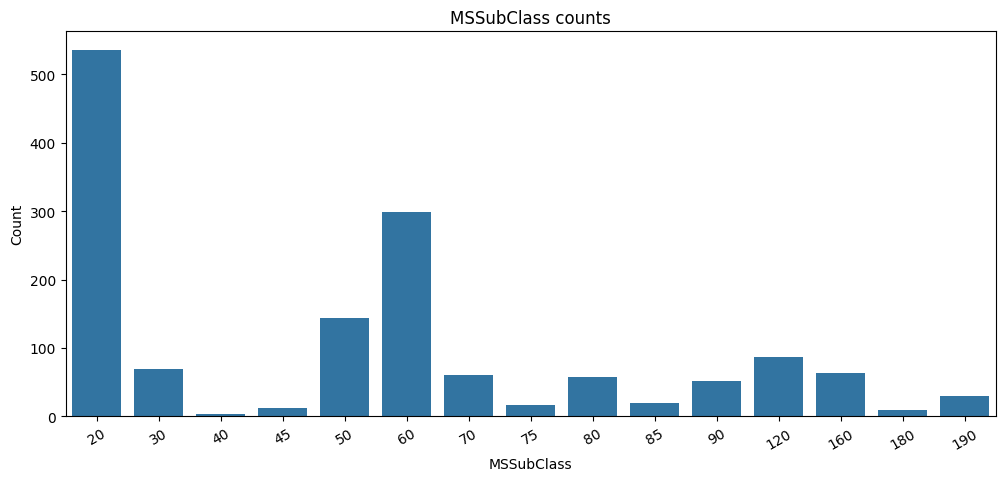

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

order = train["MSSubClass"].value_counts().sort_index().index.astype(str)
plot_df = train.copy()
plot_df["MSSubClass"] = plot_df["MSSubClass"].astype(str)

sns.countplot(
    data=plot_df,
    x="MSSubClass",
    order=order
)

plt.title("MSSubClass counts")
plt.xlabel("MSSubClass")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

### 建物タイプごとで、住宅価格の分布の可視化

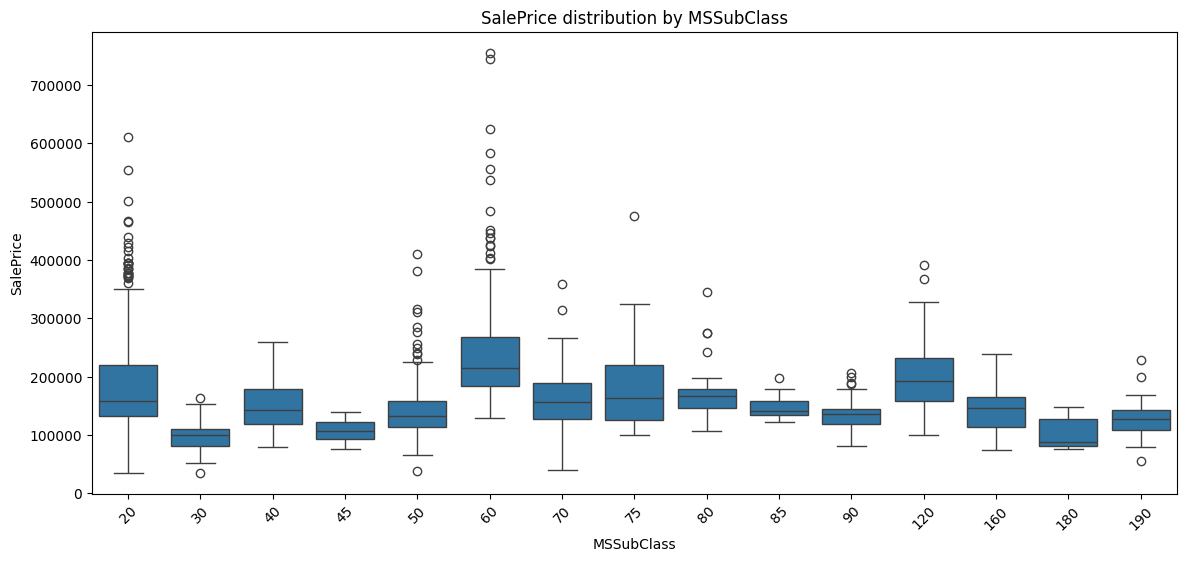

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = train.copy()
plot_df["MSSubClass"] = plot_df["MSSubClass"].astype(str)

order = train["MSSubClass"].value_counts().sort_index().index.astype(str)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x="MSSubClass",
    y="SalePrice",
    order=order
)

plt.title("SalePrice distribution by MSSubClass")
plt.xlabel("MSSubClass")
plt.ylabel("SalePrice")
plt.xticks(rotation=45)
plt.show()